# Retaining Wall Earth Pressure and a Boring Log

An invented site: a 14-ft cantilever wall retains a medium-dense sand
(γ = 121 pcf, φ = 33°) with a 250-psf construction surcharge and the water
table 9 ft below the top of the wall.

In [1]:
from civilpy.geotech.lateral_earth import (
    LateralEarthPressure, rankine_ka, rankine_kp)

ka = rankine_ka(33.0)
print(f"Ka = {ka:.3f}, Kp = {rankine_kp(33.0):.2f}")

wall = LateralEarthPressure(height=14.0, gamma=121.0, phi=33.0,
                            surcharge=250.0, water_depth=9.0)
print(f"resultant thrust = {wall.resultant / 1000:.1f} kip/ft of wall")
print(f"acting at {wall.resultant_height:.2f} ft above the base")

Ka = 0.295, Kp = 3.39
resultant thrust = 5.1 kip/ft of wall
acting at 4.82 ft above the base


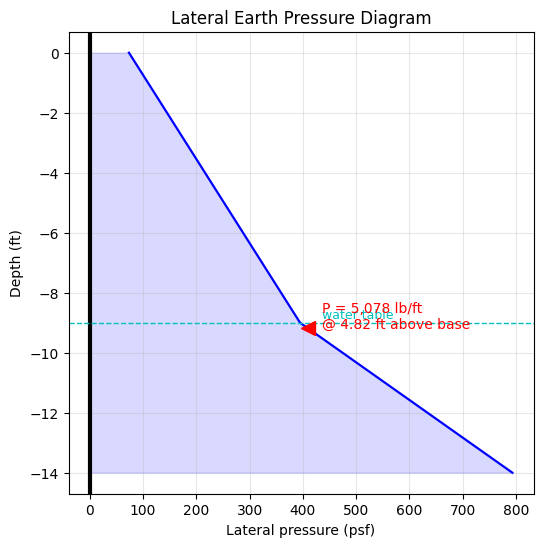

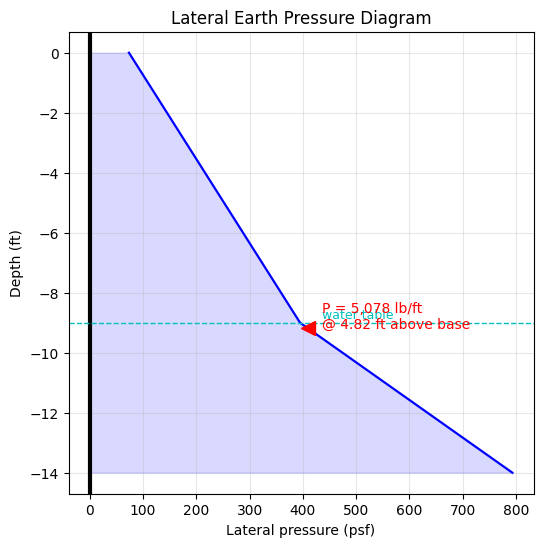

In [2]:
wall.plot()

## The boring log behind those numbers

The same invented site as a `SoilProfile`: fill over the sand over a stiff
clay, with the stress profile showing the effective-stress kink at the water
table.

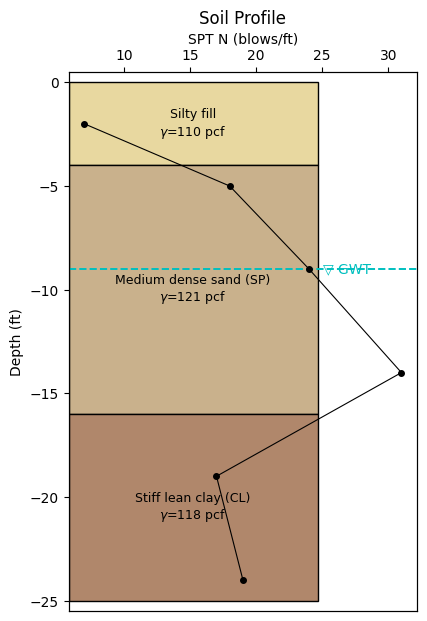

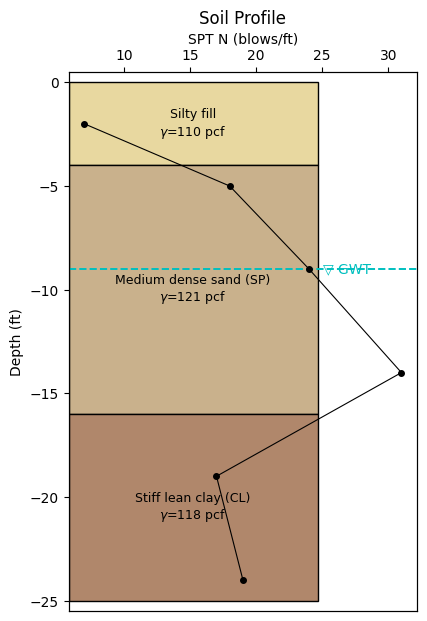

In [3]:
from civilpy.geotech.soil_profile import SoilLayer, SoilProfile

boring = SoilProfile([
    SoilLayer("Silty fill", 4.0, 110.0),
    SoilLayer("Medium dense sand (SP)", 12.0, 121.0),
    SoilLayer("Stiff lean clay (CL)", 9.0, 118.0),
], water_table=9.0)
boring.plot(spt=[(2.0, 7), (5.0, 18), (9.0, 24), (14.0, 31), (19.0, 17),
                 (24.0, 19)])

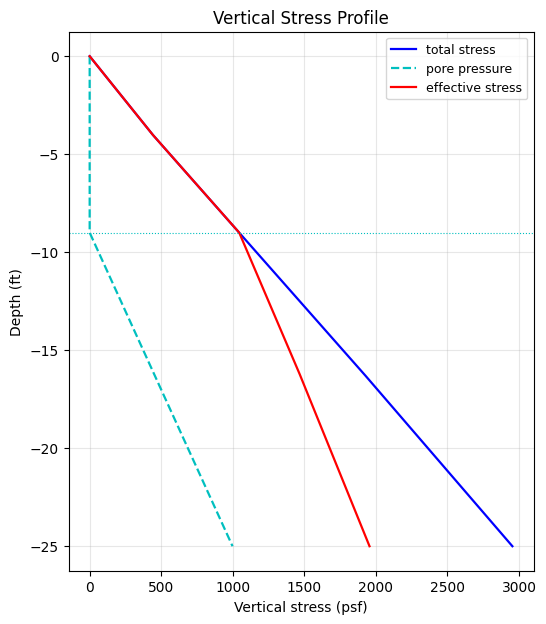

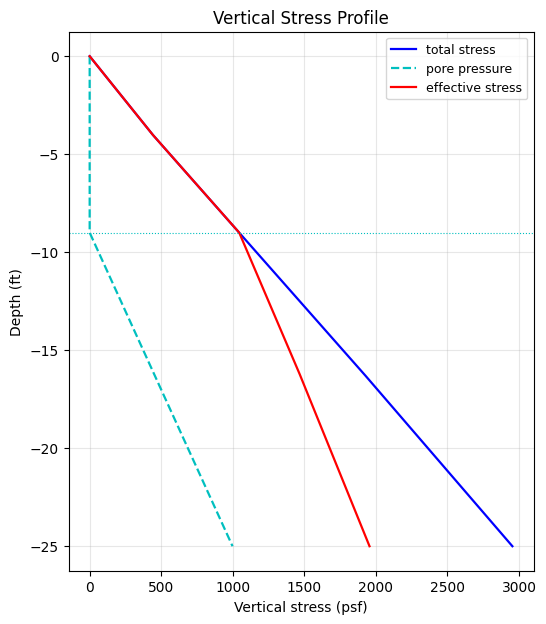

In [4]:
boring.plot_stress_profile()

Total stress grows with each layer's unit weight, pore pressure switches on at
the water table, and their difference — the effective stress — is what the
sand's friction angle acts on in the wall calculation above.